# SVM — Handwritten Digits (scikit-learn Digits)

Image-like classification with EDA, baselines, tuning, and evaluation plots.
Dataset: `sklearn.datasets.load_digits` (real).

**Author:** Olivier Robert-Duboille

**What you'll practice**
- reproducible data loading
- EDA with clear plots
- feature engineering / preprocessing pipelines
- cross-validation + hyperparameter tuning
- baseline vs advanced model comparison

This notebook is part of the *advanced-ml-mastery-collection* and is designed to be reproducible and portfolio-ready.

In [1]:
# Reproducibility
import os
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plot settings
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_context('talk')


## Load dataset

Load data into a pandas DataFrame/Series and perform a first sanity check.

(1797, 64) (1797,)


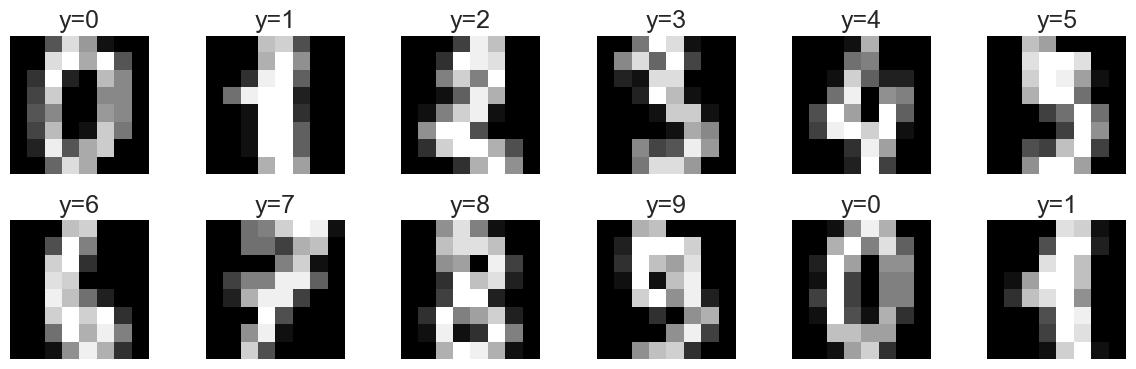

In [2]:
from sklearn.datasets import load_digits
import numpy as np
import pandas as pd

digits = load_digits()
X = digits.data
y = digits.target

print(X.shape, y.shape)

# Visualize a few digits
fig, axes = plt.subplots(2, 6, figsize=(12,4))
for ax, idx in zip(axes.ravel(), range(12)):
    ax.imshow(digits.images[idx], cmap='gray')
    ax.set_title(f'y={y[idx]}')
    ax.axis('off')
plt.tight_layout()
plt.show()


## Baselines vs SVM (CV)

In [3]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {'acc': 'accuracy', 'f1_macro': 'f1_macro'}

models = {
    'dummy': DummyClassifier(strategy='most_frequent'),
    'logreg': LogisticRegression(max_iter=3000, n_jobs=-1),
    'svm_rbf': SVC(kernel='rbf'),
}

import pandas as pd
rows = []
for name, model in models.items():
    if name in ['logreg', 'svm_rbf']:
        pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    else:
        pipe = Pipeline([('model', model)])
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({'model': name, 'acc': res['test_acc'].mean(), 'f1_macro': res['test_f1_macro'].mean()})

display(pd.DataFrame(rows).sort_values('acc', ascending=False))


,model,acc,f1_macro
2,svm_rbf,0.981211,0.981211
1,logreg,0.967995,0.967880
0,dummy,0.100905,0.018331


## Hyperparameter tuning (SVM)

In [4]:
from sklearn.model_selection import GridSearchCV
import numpy as np

pipe = Pipeline([('scaler', StandardScaler()), ('model', SVC(kernel='rbf'))])
grid = {
    'model__C': np.logspace(-1, 2, 7),
    'model__gamma': np.logspace(-4, -1, 7),
}
gs = GridSearchCV(pipe, grid, cv=cv, scoring='accuracy', n_jobs=-1)
gs.fit(X_train, y_train)
print('Best CV accuracy:', gs.best_score_)
print('Best params:', gs.best_params_)


Best CV accuracy: 0.9819081494386372
Best params: {'model__C': 3.1622776601683795, 'model__gamma': 0.01}


## Test evaluation

              precision    recall  f1-score   support

           0      1.000     1.000     1.000        36
           1      0.946     0.972     0.959        36
           2      1.000     1.000     1.000        35
           3      1.000     1.000     1.000        37
           4      0.946     0.972     0.959        36
           5      1.000     1.000     1.000        37
           6      0.973     1.000     0.986        36
           7      0.947     1.000     0.973        36
           8      1.000     0.914     0.955        35
           9      1.000     0.944     0.971        36

    accuracy                          0.981       360
   macro avg      0.981     0.980     0.980       360
weighted avg      0.981     0.981     0.980       360



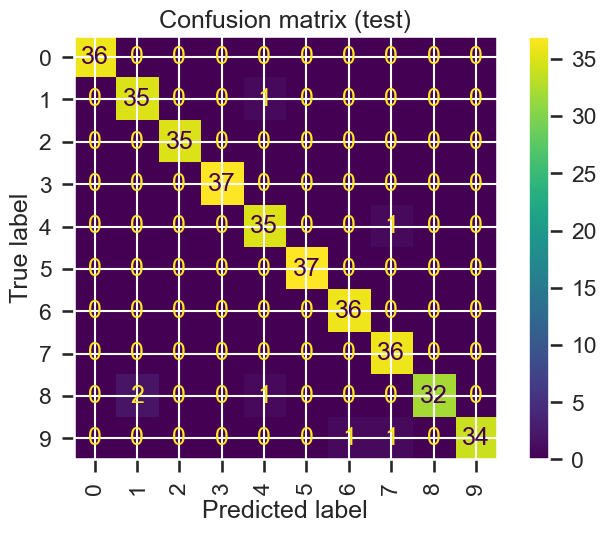

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

best = gs.best_estimator_
best.fit(X_train, y_train)
pred = best.predict(X_test)
print(classification_report(y_test, pred, digits=3))

ConfusionMatrixDisplay.from_predictions(y_test, pred, xticks_rotation='vertical')
plt.title('Confusion matrix (test)')
plt.show()
